In [72]:
import os
import pandas as pd
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
# !pip install -r /Users/ryan/github/prosodic/requirements.txt

import prosodic
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100
from tqdm.auto import tqdm

import plotnine as p9
import numpy as np

constraints={
    'w_peak':1,
    'w_stress':1,
    's_unstress':1,
    'unres_across':1,
    'unres_within':1,
    # 'pentameter':1000,
    # 'iambic':1000,
}

meter = prosodic.Meter(
    constraints=constraints,
    resolve_optionality=True,
    max_s=1,
    max_w=2,
)

def get_agent(model):
    if model == 'shakespeare':
        return 'Shakespeare'
    elif model.startswith('b.'):
        cents = int(model[3:5])+1
        return f'C{cents}'
    elif 'markov' in model.lower():
        if 'shakespeare' in model.lower():
            return 'Markov (Shakespeare)'
        else:
            return 'Markov (C17-20)'
    else:
        return 'LLM'

from collections import Counter

def find_pos_in_meter_str(meter_str):
    pos=''
    posl=[]
    for ws in meter_str:
        if pos and ws!=pos[-1]:
            posl.append(pos)
            pos=''
        pos+=ws
    if pos: posl.append(pos)
    return posl

print(find_pos_in_meter_str('--+-+-+-+'))


['--', '+', '-', '+', '-', '+', '-', '+']


In [73]:
@prosodic.cache
def get_df_smpl(sample_size=154):
    df=pd.read_pickle('data.allpoems.pkl')

    def filter_poem_txt(txt):
        vparas = [para.strip() for para in txt.split('\n\n') if '\n' in para.strip()]
        lines = [l.strip() for vpara in vparas for l in vpara.split('\n') if 20>=len(l.split())>=2 and 3<=len(l.strip()) <= 100]
        return '\n'.join(lines)

    def num_lines_txt(txt):
        return len([v for v in txt.split('\n') if v.strip()])

    df['poem_txt'] = df['poem'].apply(filter_poem_txt)
    df['num_lines_txt'] = df['poem_txt'].apply(num_lines_txt)
    df['prompt'] = df['prompt'].fillna('')
    df['agent'] = df['model'].apply(get_agent)
    df = df[df.num_lines_txt>=4]
    df = df[df.num_lines_txt<=40]
    df = df.groupby('agent').head(sample_size)
    return df[['agent','model','temp','prompt','poem_txt','num_lines_txt']]

In [74]:
df_smpl = get_df_smpl()
df_smpl

,agent,model,temp,prompt,poem_txt,num_lines_txt
0,LLM,gpt-3.5-turbo,1.240831,Write a long poem that does NOT rhyme.,"In the heart of the bustling city,\nThere lies...",30
1,LLM,gpt-3.5-turbo,0.209565,Write a poem that does NOT rhyme.,"In the stillness of the night\nI lay awake, co...",28
2,LLM,gemini-pro,0.953504,Write a poem in the style of e.e. cummings,the c\nof the\nby the task\ndrunk on pollen's ...,9
3,LLM,claude-3-opus-20240229,0.921867,Write a long poem that does NOT rhyme.,"In the depths of the forest, where shadows dan...",40
4,LLM,claude-3-opus-20240229,0.653726,Write an unryhmed poem in the style of Shakesp...,"Alas, what fate doth bring me to this pass?\nT...",15
...,...,...,...,...,...,...
1258,C20,b. 1950-2000,NaN,,"One touch, then turn, then open the defence,\n...",24
1263,C20,b. 1900-1950,NaN,,"African blues\ndoes not know me. Their steps, ...",39
1267,C20,b. 1900-1950,NaN,,"The Northern Crown, nearby Arcturus\nin the me...",14
1274,C20,b. 1900-1950,NaN,,"Smoke is my neighbour's crop, His plot\nis one...",22


In [75]:
def parse_poem(poem_txt, force=False, parse_stash=None):
    if not force and parse_stash is not None:
        parse_df = parse_stash.get(poem_txt)
        if parse_df is not None:
            return parse_df
    
    try:
        poem = prosodic.Text(txt=poem_txt)
        parses = poem.parse(meter=meter,num_proc=4)
        parse_df = parses.best.df
        if parse_stash is not None:
            parse_stash.set(poem_txt, parse_df)
        return parse_df
    except Exception as e:
        return pd.DataFrame()
    

In [76]:
# parse_poem(df_smpl.iloc[0].poem_txt, parse_stash=prosodic.HashStash())

In [79]:
 
def get_flex_parses_df(df, force=False, fn='data.flex_parses_smpl.pkl'):
    parse_dfs = []
    if not force and os.path.exists(fn):
        parses_df = pd.read_pickle(fn)
    else:
        parse_stash = prosodic.HashStash(fn+'.db', serializer='pickle', engine='lmdb')
        parse_dfs = []
        for i,row in tqdm(df.iterrows(), desc='Parsing texts', total=len(df)):
            parse_df = parse_poem(row.poem_txt, parse_stash=parse_stash).reset_index()
            parse_df = parse_df.assign(
                agent = row.agent,
                model = row.model, 
                poem_num=i+1, 
            )
            parse_dfs.append(parse_df)

        parses_df = pd.concat(parse_dfs)
        parses_df = parses_df[['poem_num'] + [c for c in parses_df if c != 'poem_num']]
        parses_df.to_pickle(fn)

    parses_df = parses_df.query('parse_num_sylls>=4')
    return parses_df


In [81]:
# flex_parses_df = get_flex_parses_df(force=True)
flex_parses_df = get_flex_parses_df(df_smpl, force=False)
# flex_parses_df

In [82]:


def get_figdf_flex_poems(parses_df=None):
    if parses_df is None:
        parses_df = get_flex_parses_df(df_smpl, force=False)
    ld=[]
    for g,gdf in parses_df.groupby('poem_num'):
        parse_meters = ''.join(gdf.parse_meter)
        parse_meters_4thpos = gdf.parse_meter.apply(lambda x: int(x[3]=='+'))
        parse_meter_count = Counter(find_pos_in_meter_str(parse_meters))
        
        d = {'poem_num':g, 'parse_meter_4thpos':parse_meters_4thpos.mean(), 'agent':gdf.iloc[0].agent, 'model':gdf.iloc[0].model,
             'mpos_ww':parse_meter_count['--'] / parse_meter_count.total()}
        ld.append(d)
    figdf = pd.DataFrame(ld)#.merge(parses_df.drop_duplicates('poem_num'), on='poem_num', how='left')
    return figdf

figdf_flex_poems = get_figdf_flex_poems(flex_parses_df)
figdf_flex_poems

,poem_num,parse_meter_4thpos,agent,model,mpos_ww
0,1,0.366667,LLM,gpt-3.5-turbo,0.158120
1,2,0.511111,LLM,gpt-3.5-turbo,0.152482
2,3,0.750000,LLM,gemini-pro,0.111111
3,4,0.625000,LLM,claude-3-opus-20240229,0.140523
4,5,0.400000,LLM,claude-3-opus-20240229,0.035433
...,...,...,...,...,...
656,1248,0.480000,C20,b. 1900-1950,0.108247
657,1259,0.958333,C20,b. 1950-2000,0.026087
658,1264,0.607143,C20,b. 1900-1950,0.132231
659,1275,0.476190,C20,b. 1900-1950,0.109589


In [93]:
def plot_hood_space(figdf=None):
    if figdf is None:
        figdf = get_figdf_flex_poems().copy()

    figdf['mpos_ww']*=100
    figdf['parse_meter_4thpos']*=100

    p9.options.figure_size = (9, 8)
    title='Upper left-hand is iambic meter'
    title+='\nThe further up, the more rising the meter'
    title+='\nThe further right, the more ternary the meter'
    fig = (
        p9.ggplot(figdf, p9.aes(x="mpos_ww", y="parse_meter_4thpos", color='agent', label='agent'))
        + p9.geom_point(size=1, alpha=.5)
        + p9.geom_density_2d(size=1.25, alpha=.8)
        + p9.geom_label(size=9, data=figdf.groupby(['agent']).median(numeric_only=True).reset_index())
        # + p9.facet_wrap('agent',ncol=2)
        # + p9.facet_wrap('agent')
        + p9.theme_classic()
        + p9.theme(legend_position='none')
        + p9.scale_color_brewer(type='qual', palette='Set2')
        + p9.scale_x_continuous(limits=(0,40))
        + p9.scale_y_continuous(limits=(0,100))
        + p9.labs(y='% Lines rising', x='% Feet ternary', caption=title, title='Metrical Space')
    )
    fig.save('../../generative-humanities/Figures/HoodSpace.AllPoems.png')
    return fig


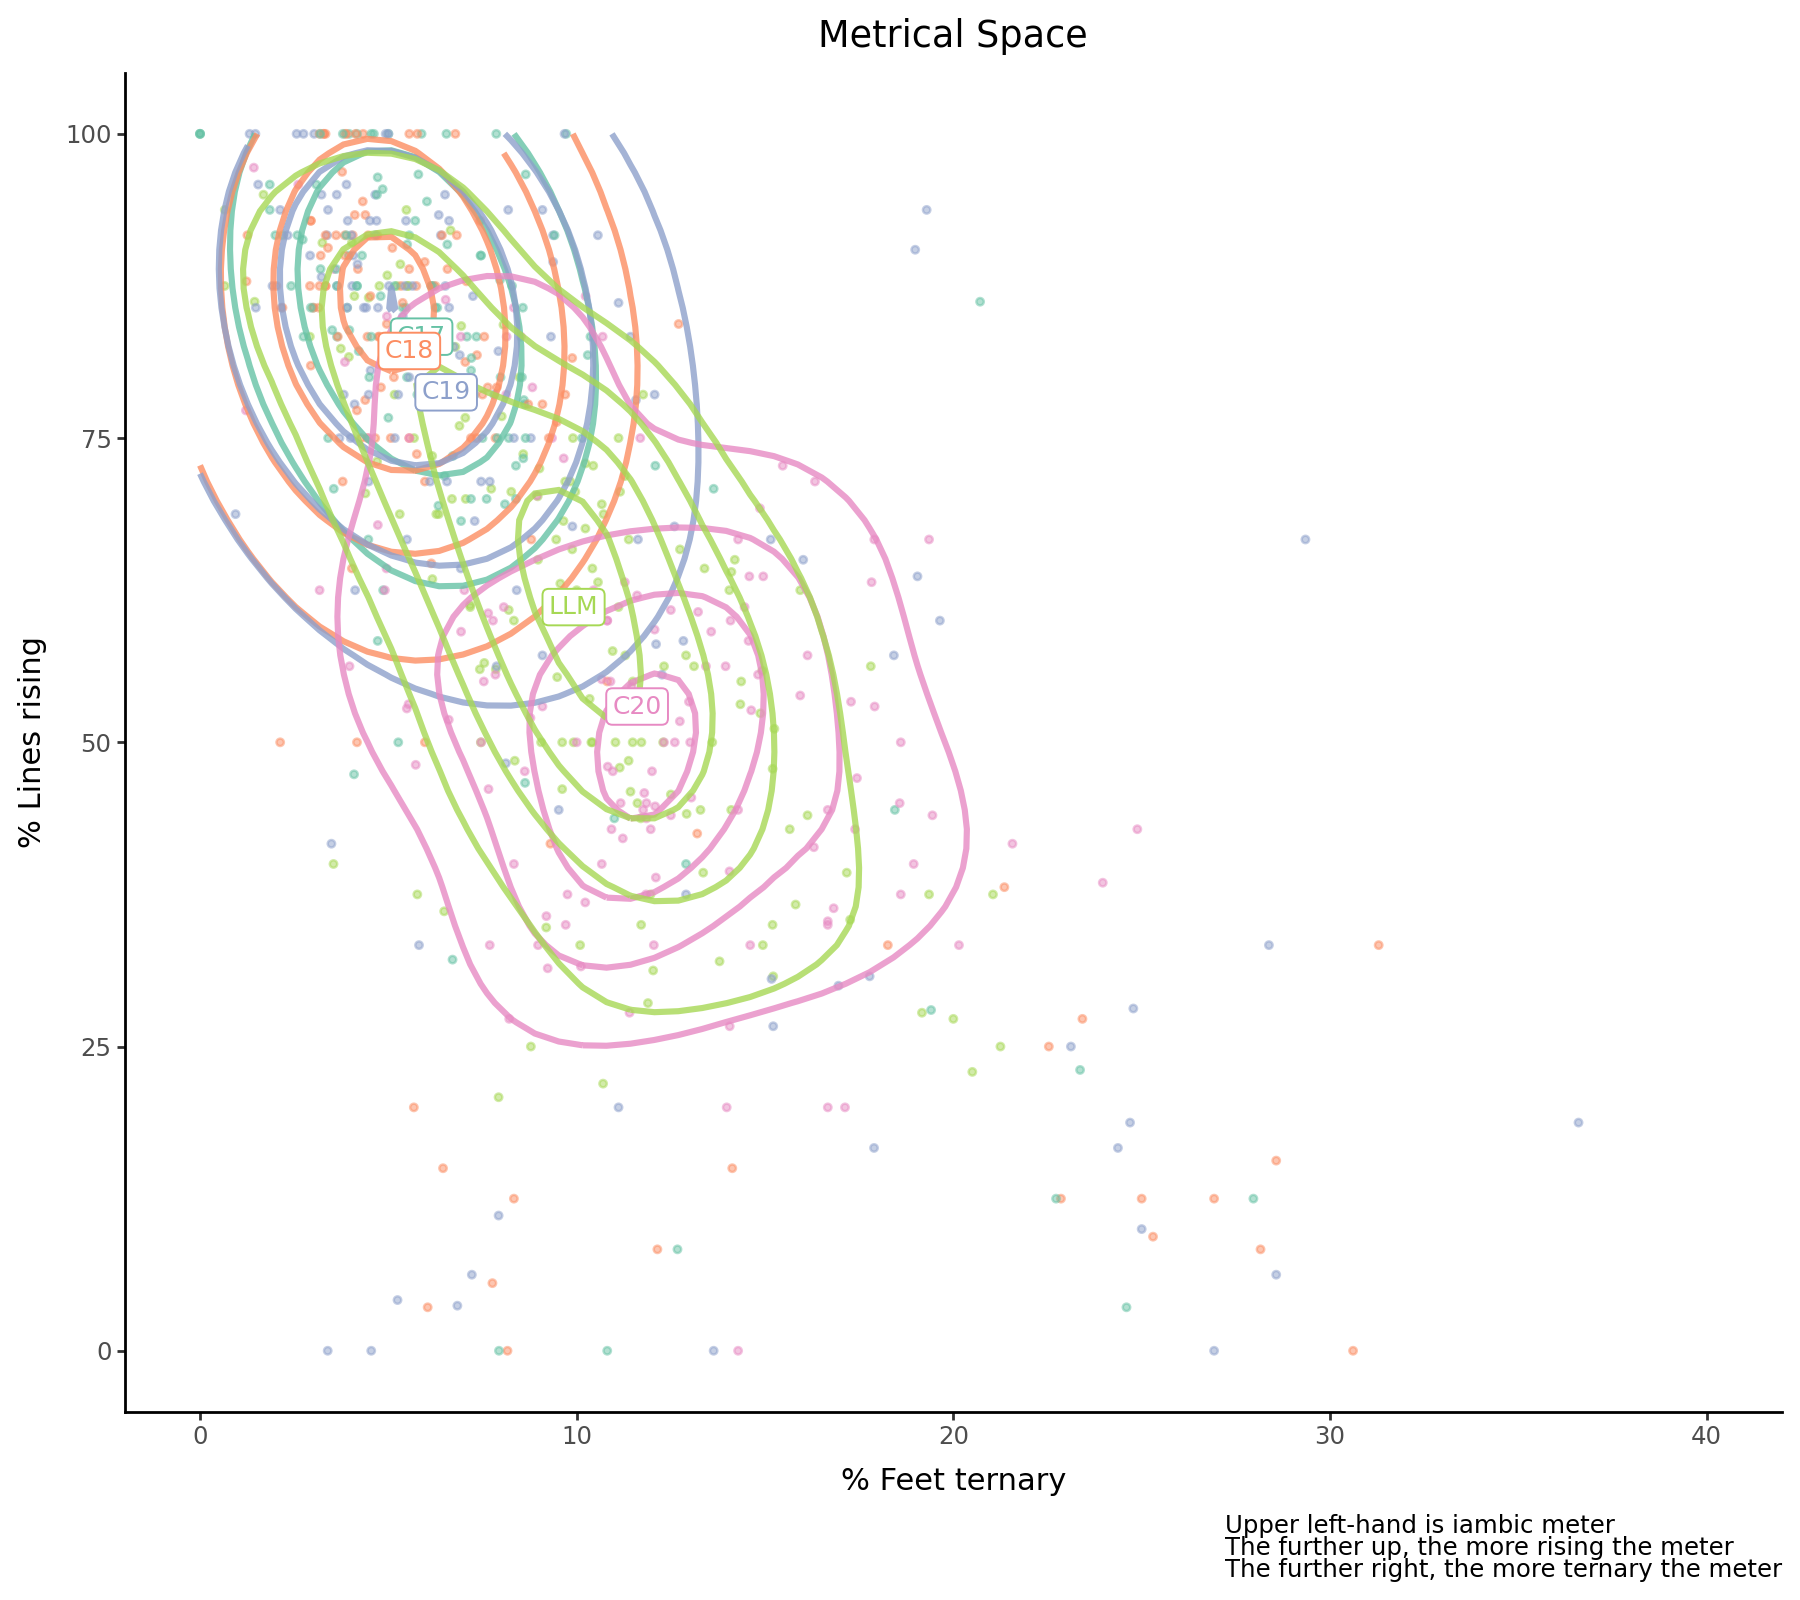

In [94]:
plot_hood_space()

In [32]:
import plotnine as p9

def get_figdf_iambic_pentameter(parses_df):
    figdf = parses_df.reset_index()

    figdf['agent'] = figdf['model'].apply(get_agent)
    figdf = figdf[~figdf['agent'].isin({'Markov2'})]

    figdf = pd.concat(
        gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
        for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
    )
    figdf = figdf.query('meter_syll_num <= 10')

    def get_line_num_type(line_num):
        if line_num in [1,2,3,4]:
            return 'Q1'
        elif line_num in [5,6,7,8]:
            return 'Q2'
        elif line_num in [9,10,11,12]:
            return 'Q3'
        elif line_num in [13,14]:
            return 'CC'

    figdf['line_num_type'] = figdf['line_num'].apply(get_line_num_type)

    # Get violation columns (those starting with *)
    viol_cols = [col for col in figdf.columns if col.startswith('*')]

    # Melt the DataFrame
    figdf_melted = pd.melt(
        figdf,
        id_vars=['meter_syll_num','line_num','agent'],
        value_vars=viol_cols,
        var_name='violation_type',
        value_name='violation_value'
    )
    figdf_melted['violation_value']*=100
    # Clean up violation_type names by removing the *
    figdf_melted['violation_type'] = figdf_melted['violation_type'].str.replace('*', '')

    p9.options.figure_size = (8, 6)
    figdf_melted['label'] = figdf_melted['violation_value'].apply(lambda x: f'{int(round(x*100))}%')

    violnames = {
        's_unstress': '*Lapse (Missing stress in strong position)',
        'w_stress': '*Clash (Unexpected stress in weak position)',
        'w_peak': '*Peak (Unexpected polysyllabic stress in weak position)',
        # 'unres_across': '*Unresolved across',
        # 'unres_within': '*Unresolved within',
    }

    figdf_melted['violation_type'] = figdf_melted['violation_type'].apply(lambda x: violnames.get(x, x))
    figdf_melted['meter_syll_num'] = pd.Categorical(figdf_melted['meter_syll_num'].astype(int))

    figdf_melted = figdf_melted[figdf_melted.violation_type.isin(set(violnames.values()))]
    figdf_melted['violation_type'] = pd.Categorical(figdf_melted['violation_type'], categories=list(violnames.values()))
    figdf_melted.agent.value_counts()

    return figdf_melted

figdf_melted = get_figdf_iambic_pentameter(flex_parses_df)

In [ ]:

import numpy as np
# Calculate mean and standard error for the line plot
line_data = (figdf_melted
             .groupby(['meter_syll_num','violation_type','agent'])
             .agg({
                 'violation_value': ['mean', 'std', 'count']
             })
             .reset_index())
line_data.columns = ['meter_syll_num', 'violation_type', 'agent', 'mean', 'std', 'count']
line_data['violation_value'] = line_data['mean']
line_data['se'] = line_data['std'] / np.sqrt(line_data['count'])
def safe_add(a, b):
    try:
        return a + b
    except TypeError:
        return float('nan')

def safe_subtract(a, b):
    try:
        return a - b
    except TypeError:
        return float('nan')

line_data['upper'] = line_data.apply(lambda row: safe_add(row['mean'], row['se']), axis=1)
line_data['lower'] = line_data.apply(lambda row: safe_subtract(row['mean'], row['se']), axis=1)
line_data['group'] = line_data['agent'].astype(str)# + '_' + line_data['violation_type'].astype(str)
line_data = line_data.query('mean>0')
line_data = line_data.sort_values(['group','meter_syll_num'])
line_data

In [ ]:
figdf_now = figdf_melted#.query('label != "0%"')
# line_data['line_count'] = line_data['count'] / 14


p9.options.figure_size = (10, 10)

fig = (p9.ggplot(figdf_now, 
                 p9.aes(x='meter_syll_num', 
                        y='violation_value',
                        color='agent')) + 
       p9.geom_line(p9.aes(group='agent'), size=.5, data=line_data, alpha=.5) +
 
       p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=line_data, width=.35, size=.8, alpha=.5) +
       p9.geom_text(p9.aes(label='agent'),size=8, data=line_data.query('mean>0'), position=p9.position_nudge(x=.25)) +
       p9.geom_point(p9.aes(shape='agent'), data=line_data, alpha=.5) +
       p9.scale_size_continuous(range=[1,3]) +
       p9.theme_classic() +
#        p9.facet_grid('violation_type~agent', scales='free_y') +
#        p9.facet_wrap('agent', scales='free_y') +
       p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
       p9.scale_color_brewer(type='qual', palette='Set1') +
       p9.labs(x='Syllable Position', 
               y='Violation Rate',
               fill='Violation Type',
               title='Metrical rule violations to iambic pentameter by syllable'
               ))
fig = fig + p9.theme(legend_position='bottom')
fig.save('../../generative-humanities/Figures/ViolsBySyll.png')
fig